# AGORA (AI Governance & Regulatory Archive) — Data Analysis
### AISI Project | Dataset 5 of 5

This notebook loads, combines, cleans, and explores the **ETO AGORA** dataset — a living collection of AI-specific laws, regulations, standards, and governance documents from the US and worldwide.

**Four source files:** `documents` (core metadata + 77 tags), `segments` (granular annotation), `authorities` (issuing bodies), `collections` (thematic groups)

**AISI Role:** Powers the **Governance Readiness** dimension (9% weight) — measuring maturity and breadth of a country's AI governance framework.

---

## 1. Setup & Data Loading

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

# ── Style Configuration ──
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#0D1117',
    'text.color': '#C9D1D9', 'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E', 'ytick.color': '#8B949E',
    'axes.edgecolor': '#21262D', 'grid.color': '#21262D', 'grid.alpha': 0.6,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'figure.dpi': 120,
})

C = {
    'accent': '#58A6FF', 'accent2': '#3FB950', 'accent3': '#D29922',
    'accent4': '#F778BA', 'accent5': '#BC8CFF', 'danger': '#F85149',
    'muted': '#484F58', 'bg': '#0D1117', 'surface': '#161B22',
    'border': '#21262D', 'text': '#C9D1D9', 'text_dim': '#8B949E',
    'cyan': '#39D2C0', 'orange': '#F97316',
}

# Tag domain colors
DOMAIN_COLORS = {
    'Applications': C['accent'], 'Harms': C['danger'], 'Incentives': C['accent3'],
    'Risk factors': C['accent4'], 'Strategies': C['accent2'],
}

OUT = '/Users/shadowclone/Documents/aisi/datasets/agora/output/'
print('Setup complete ✓')

Setup complete ✓


In [2]:
# ── Load all 4 AGORA files ──
DATA_DIR = '/Users/shadowclone/Documents/aisi/datasets/agora/'

docs = pd.read_csv(f'{DATA_DIR}documents.csv', encoding='utf-8-sig')
segs = pd.read_csv(f'{DATA_DIR}segments.csv', encoding='utf-8-sig', low_memory=False)
auth = pd.read_csv(f'{DATA_DIR}authorities.csv', encoding='utf-8-sig')
coll = pd.read_csv(f'{DATA_DIR}collections.csv', encoding='utf-8-sig')

print('Loaded 4 tables:')
for name, df in [('documents', docs), ('segments', segs), 
                  ('authorities', auth), ('collections', coll)]:
    print(f'  {name:15s} → {df.shape[0]:>7,} rows × {df.shape[1]:>3} cols')

Loaded 4 tables:
  documents       →     973 rows × 100 cols
  segments        →   8,116 rows ×  87 cols
  authorities     →     105 rows ×   3 cols
  collections     →      10 rows ×   2 cols


---
## 2. Individual Table Inspection

### 2.1 Documents Table
Core table: 973 AI governance documents with metadata, summaries, and 77 thematic tags.

In [3]:
print(f'Shape: {docs.shape}')
print(f'\nColumns by category:')

meta_cols = ['AGORA ID', 'Official name', 'Casual name', 'Link to document', 'Authority',
             'Collections', 'Most recent activity', 'Most recent activity date', 'Proposed date',
             'Annotated?', 'Validated?', 'Primarily applies to the government',
             'Primarily applies to the private sector', 'Short summary', 'Long summary', 'Tags',
             'Summaries and tags may include unreviewed machine output',
             'Official plaintext retrieved', 'Official plaintext source',
             'Official plaintext unavailable/infeasible', 'Official pdf source',
             'Official pdf retrieved', 'Number of segments created']
tag_cols = [c for c in docs.columns if c.startswith(('Applications:', 'Harms:', 'Incentives:',
                                                      'Risk factors:', 'Strategies:'))]

print(f'  Metadata columns:  {len(meta_cols)}')
print(f'  Tag columns:       {len(tag_cols)} (across 5 domains)')

# Tag domains
tag_domains = {}
for c in tag_cols:
    domain = c.split(':')[0]
    tag_domains[domain] = tag_domains.get(domain, 0) + 1
print(f'\nTag domains:')
for domain, count in tag_domains.items():
    print(f'  {domain:20s}: {count:>2} tags')
print(f'  Total: {len(tag_cols)} tags')

Shape: (973, 100)

Columns by category:
  Metadata columns:  23
  Tag columns:       77 (across 5 domains)

Tag domains:
  Applications        : 19 tags
  Harms               :  8 tags
  Incentives          :  6 tags
  Risk factors        : 10 tags
  Strategies          : 34 tags
  Total: 77 tags


In [4]:
# ── Document status distribution ──
print('Document status:')
print(docs['Most recent activity'].value_counts().to_string())

print(f'\nAnnotation status:')
print(f'  Annotated: {docs["Annotated?"].sum()} / {len(docs)} ({docs["Annotated?"].mean():.0%})')
print(f'  Validated: {docs["Validated?"].sum()} / {len(docs)} ({docs["Validated?"].mean():.0%})')
print(f'  Machine output flagged: {docs["Summaries and tags may include unreviewed machine output"].sum()}')

print(f'\nApplicability:')
print(f'  Primarily government: {docs["Primarily applies to the government"].sum()}')
print(f'  Primarily private sector: {docs["Primarily applies to the private sector"].sum()}')

print(f'\nDate range (proposed):')
docs['proposed_year'] = pd.to_datetime(docs['Proposed date'], errors='coerce').dt.year
print(f'  {docs.proposed_year.min():.0f} – {docs.proposed_year.max():.0f}')

Document status:
Most recent activity
Enacted     450
Defunct     400
Proposed    123

Annotation status:
  Annotated: 527 / 973 (54%)
  Validated: 216 / 973 (22%)
  Machine output flagged: 443

Applicability:
  Primarily government: 364
  Primarily private sector: 142

Date range (proposed):
  2016 – 2025


In [5]:
# ── Authority distribution ──
print(f'Unique authorities: {docs.Authority.nunique()}')
print(f'\nTop 15 authorities by document count:')
print(docs.Authority.value_counts().head(15).to_string())

Unique authorities: 97

Top 15 authorities by document count:
Authority
United States Congress               582
California                            34
Chinese central government            23
New York                              19
Private-sector companies              17
Illinois                              13
Other multinational                   13
Food and Drug Administration          12
Executive Office of the President     12
New Jersey                            11
Other authorities                     10
Massachusetts                          8
Washington                             8
Utah                                   8
Rhode Island                           7


In [6]:
# ── Collections distribution ──
print('Collections (multi-value field):')
all_colls = docs['Collections'].dropna().str.split(';').explode().str.strip()
print(all_colls.value_counts().to_string())

Collections (multi-value field):
Collections
U.S. federal laws                                          557
U.S. state and local documents                             246
NDAA provisions                                            111
Editors' Picks                                              51
U.S. regulations, executive orders, and agency policies     48
Chinese law and policy                                      31
Miscellaneous documents                                     28
FY2025 NDAA                                                 23
Multinational                                               19
Corporate policies and commitments                          17


### 2.2 Segments Table
Granular annotation: documents broken into segments, each with its own tags.

In [7]:
print(f'Shape: {segs.shape}')
print(f'Unique documents: {segs["Document ID"].nunique()}')
print(f'Segments per document: mean={segs.groupby("Document ID").size().mean():.1f}, '
      f'median={segs.groupby("Document ID").size().median():.0f}, '
      f'max={segs.groupby("Document ID").size().max()}')

print(f'\nSpecial flags:')
if 'Non-operative' in segs.columns:
    print(f'  Non-operative segments: {segs["Non-operative"].sum()}')
if 'Not AI-related' in segs.columns:
    print(f'  Not AI-related segments: {segs["Not AI-related"].sum()}')
if 'Segment annotated' in segs.columns:
    print(f'  Annotated: {segs["Segment annotated"].sum()} / {len(segs)}')
if 'Segment validated' in segs.columns:
    print(f'  Validated: {segs["Segment validated"].sum()} / {len(segs)}')

Shape: (8116, 87)
Unique documents: 972
Segments per document: mean=8.3, median=5, max=254

Special flags:
  Non-operative segments: 314
  Not AI-related segments: 368
  Annotated: 3474 / 8116
  Validated: 725 / 8116


### 2.3 Authorities Table
Issuing bodies with jurisdiction and parent authority mapping.

In [8]:
print(f'Shape: {auth.shape}')
print(f'\nJurisdictions:')
print(auth['Jurisdiction'].value_counts().to_string())
print(f'\nParent authorities:')
print(auth['Parent authority'].value_counts().head(10).to_string())
auth.head(10)

Shape: (105, 3)

Jurisdictions:
Jurisdiction
United States      89
Other countries     8
Multinational       4
China               2

Parent authorities:
Parent authority
State governments     51
Federal government    20
Local governments     15


,Name,Jurisdiction,Parent authority
0,Private-sector companies,NaN,NaN
1,Other authorities,NaN,NaN
2,Chinese provincial and local governments,China,NaN
3,Chinese central government,China,NaN
4,European Union,Multinational,NaN
5,OECD,Multinational,NaN
6,United Nations,Multinational,NaN
7,Other multinational,Multinational,NaN
8,Government of Israel,Other countries,NaN
9,Government of the United Kingdom,Other countries,NaN


### 2.4 Collections Table

In [9]:
print(f'Shape: {coll.shape}')
print(f'\nCollections:')
for _, row in coll.iterrows():
    print(f'  {row["Name"]}')
    print(f'    {str(row["Description"])[:100]}')
    print()

Shape: (10, 2)

Collections:
  Miscellaneous documents
    Documents not covered in other collections.

  FY2025 NDAA
    AI-related provisions from the National Defense Authorization Act for fiscal year 2025.

  U.S. state and local documents
    AI-related laws from U.S. states and localities (not comprehensive).

  U.S. federal laws
    AI-related federal laws, both proposed and enacted.

  Chinese law and policy
    AI-related laws, policies, and plans from China.

  U.S. regulations, executive orders, and agency policies
    U.S. federal regulations and other AI-related documents from the executive branch.

  Multinational
    Notable AI governance documents from multinational organizations and venues.

  NDAA provisions
    AI-related provisions from recent National Defense Authorization Acts.

  Editors' Picks
    Notable AI governance documents from the U.S. and around the world. Selected by ETO and CSET researc

  Corporate policies and commitments
    AI governance pledges an

---
## 3. Combining Tables Into Master Dataset

We enrich the documents table with jurisdiction data from authorities, creating a country-mappable governance dataset.

In [10]:
# ── Step 1: Map documents to jurisdictions via authorities ──
master = docs.merge(
    auth[['Name', 'Jurisdiction', 'Parent authority']],
    left_on='Authority',
    right_on='Name',
    how='left',
    suffixes=('', '_auth')
).drop(columns=['Name_auth'], errors='ignore')

print(f'After authority join: {master.shape}')
print(f'\nJurisdiction coverage:')
print(master['Jurisdiction'].value_counts().to_string())
print(f'\nUnmapped: {master.Jurisdiction.isna().sum()}')

After authority join: (973, 104)

Jurisdiction coverage:
Jurisdiction
United States      882
China               26
Multinational       20
Other countries     18

Unmapped: 27


In [11]:
# ── Step 2: Map jurisdictions to countries for AISI ──
# US sub-authorities (states, federal) → 'United States'
# The jurisdiction field already does this — most entries are 'United States'
master['country'] = master['Jurisdiction'].copy()

# Map 'Other countries' → try to extract from authority name (best effort)
# For now, keep as-is — these are a small minority
print('Country mapping for AISI:')
print(master['country'].value_counts().to_string())
print(f'\n⚠️ "Other countries" ({(master.country=="Other countries").sum()} docs) are from various '
      'non-US/non-China jurisdictions not yet well-covered in AGORA')

Country mapping for AISI:
country
United States      882
China               26
Multinational       20
Other countries     18

⚠️ "Other countries" (18 docs) are from various non-US/non-China jurisdictions not yet well-covered in AGORA


In [12]:
# ── Step 3: Identify tag columns and normalize boolean values ──
tag_cols = [c for c in master.columns if c.startswith(('Applications:', 'Harms:', 'Incentives:',
                                                        'Risk factors:', 'Strategies:'))]

# Normalize to boolean (handle mixed TRUE/True/1/False/NaN)
for col in tag_cols:
    master[col] = master[col].apply(
        lambda x: True if str(x).strip().upper() in ('TRUE', '1') else False
    )

# Count tags per document
master['num_tags'] = master[tag_cols].sum(axis=1)

# Count tags by domain
for domain in ['Applications', 'Harms', 'Incentives', 'Risk factors', 'Strategies']:
    domain_cols = [c for c in tag_cols if c.startswith(domain)]
    master[f'num_{domain.lower().replace(" ", "_")}_tags'] = master[domain_cols].sum(axis=1)

print(f'Tag normalization complete.')
print(f'Tags per document: mean={master.num_tags.mean():.1f}, median={master.num_tags.median():.0f}, max={master.num_tags.max()}')
print(f'Documents with 0 tags: {(master.num_tags==0).sum()} ({(master.num_tags==0).mean():.0%})')

Tag normalization complete.
Tags per document: mean=5.5, median=2, max=60
Documents with 0 tags: 457 (47%)


In [13]:
# ── Step 4: Compute AISI Governance Readiness metrics ──
# Per-jurisdiction aggregation
enacted = master[master['Most recent activity'] == 'Enacted'].copy()

governance_metrics = master.groupby('country').agg(
    total_docs=('AGORA ID', 'count'),
    enacted_docs=('Most recent activity', lambda x: (x == 'Enacted').sum()),
    proposed_docs=('Most recent activity', lambda x: (x == 'Proposed').sum()),
    defunct_docs=('Most recent activity', lambda x: (x == 'Defunct').sum()),
    avg_tags_per_doc=('num_tags', 'mean'),
    annotated_docs=('Annotated?', 'sum'),
    gov_focused=('Primarily applies to the government', 'sum'),
    private_focused=('Primarily applies to the private sector', 'sum'),
).reset_index()

# Maturity ratio: enacted / total
governance_metrics['maturity_ratio'] = (
    governance_metrics['enacted_docs'] / governance_metrics['total_docs']
)

# Thematic breadth: unique tags used across enacted docs per jurisdiction
thematic_breadth = enacted.groupby('country')[tag_cols].any().sum(axis=1).reset_index(name='thematic_breadth')
governance_metrics = governance_metrics.merge(thematic_breadth, on='country', how='left')
governance_metrics['thematic_breadth'] = governance_metrics['thematic_breadth'].fillna(0).astype(int)

governance_metrics = governance_metrics.sort_values('enacted_docs', ascending=False)

print('AISI Governance Readiness — Jurisdiction Metrics:')
print('=' * 90)
print(governance_metrics.to_string(index=False, float_format='%.2f'))

AISI Governance Readiness — Jurisdiction Metrics:
        country  total_docs  enacted_docs  proposed_docs  defunct_docs  avg_tags_per_doc  annotated_docs  gov_focused  private_focused  maturity_ratio  thematic_breadth
  United States         882           390             94           398              4.76             473          349              114            0.44                76
          China          26            18              8             0              7.23              12            0                9            0.69                46
  Multinational          20            17              3             0             14.70              12            7                2            0.85                63
Other countries          18            10              8             0             10.44              10            6                4            0.56                42


---
## 4. Data Cleaning & Quality Assessment

In [14]:
# ── 4.1 US dominance ──
print('⚠️ AGORA is heavily US-skewed:')
us_pct = (master.country == 'United States').mean()
print(f'  US documents: {(master.country=="United States").sum()} / {len(master)} ({us_pct:.0%})')
print(f'  China: {(master.country=="China").sum()}')
print(f'  Multinational: {(master.country=="Multinational").sum()}')
print(f'  Other: {(master.country=="Other countries").sum()}')
print(f'\n  → Governance Readiness dimension weighted at 9% to account for this bias')
print(f'  → Coverage-weighted composite will further downweight for non-US countries')

⚠️ AGORA is heavily US-skewed:
  US documents: 882 / 973 (91%)
  China: 26
  Multinational: 20
  Other: 18

  → Governance Readiness dimension weighted at 9% to account for this bias
  → Coverage-weighted composite will further downweight for non-US countries


In [15]:
# ── 4.2 Annotation completeness ──
print('Annotation pipeline status:')
print(f'  Annotated (human-reviewed): {master["Annotated?"].sum()} / {len(master)} ({master["Annotated?"].mean():.0%})')
print(f'  Validated (dual-reviewed):  {master["Validated?"].sum()} / {len(master)} ({master["Validated?"].mean():.0%})')
print(f'  Machine output flagged:     {master["Summaries and tags may include unreviewed machine output"].sum()}')
print(f'\n  → {master["Annotated?"].mean():.0%} annotation rate is adequate for AISI')
print(f'  → Unannotated docs still have machine-generated summaries/tags')

Annotation pipeline status:
  Annotated (human-reviewed): 527 / 973 (54%)
  Validated (dual-reviewed):  216 / 973 (22%)
  Machine output flagged:     443

  → 54% annotation rate is adequate for AISI
  → Unannotated docs still have machine-generated summaries/tags


In [16]:
# ── 4.3 Documents with zero tags ──
zero_tags = master[master.num_tags == 0]
print(f'Documents with 0 tags: {len(zero_tags)} ({len(zero_tags)/len(master):.0%})')
print(f'\nBreakdown by status:')
print(zero_tags['Most recent activity'].value_counts().to_string())
print(f'\nBreakdown by annotation:')
print(f'  Annotated: {zero_tags["Annotated?"].sum()} / {len(zero_tags)}')
print(f'  → Most zero-tag docs are unannotated — tags pending human/machine review')

Documents with 0 tags: 457 (47%)

Breakdown by status:
Most recent activity
Defunct     207
Enacted     181
Proposed     69

Breakdown by annotation:
  Annotated: 11 / 457
  → Most zero-tag docs are unannotated — tags pending human/machine review


In [17]:
# ── 4.4 Date quality ──
print('Date coverage:')
print(f'  Proposed date filled: {docs["Proposed date"].notna().sum()} / {len(docs)}')
print(f'  Activity date filled: {docs["Most recent activity date"].notna().sum()} / {len(docs)}')

master['activity_year'] = pd.to_datetime(master['Most recent activity date'], errors='coerce').dt.year
print(f'\nDocuments by activity year (enacted only):')
enacted_years = master[master['Most recent activity']=='Enacted']['activity_year'].value_counts().sort_index()
print(enacted_years.to_string())

Date coverage:
  Proposed date filled: 826 / 973
  Activity date filled: 973 / 973

Documents by activity year (enacted only):
activity_year
2016      1
2017      2
2018      3
2019     15
2020     14
2021     57
2022     73
2023     90
2024    164
2025     31


---
## 5. Save Combined & Cleaned Datasets

In [19]:
# ── Save master ──
master.to_csv(f'{OUT}agora_master.csv', index=False)
print(f'✅ Saved: agora_master.csv → {master.shape[0]:,} rows × {master.shape[1]} columns')

# ── Save governance metrics for AISI ──
governance_metrics.to_csv(f'{OUT}agora_governance_metrics.csv', index=False)
print(f'✅ Saved: agora_governance_metrics.csv → {governance_metrics.shape[0]} jurisdictions')

✅ Saved: agora_master.csv → 973 rows × 112 columns
✅ Saved: agora_governance_metrics.csv → 4 jurisdictions


---
## 6. Exploratory Analysis & Visualizations

### 6.1 Dataset Overview

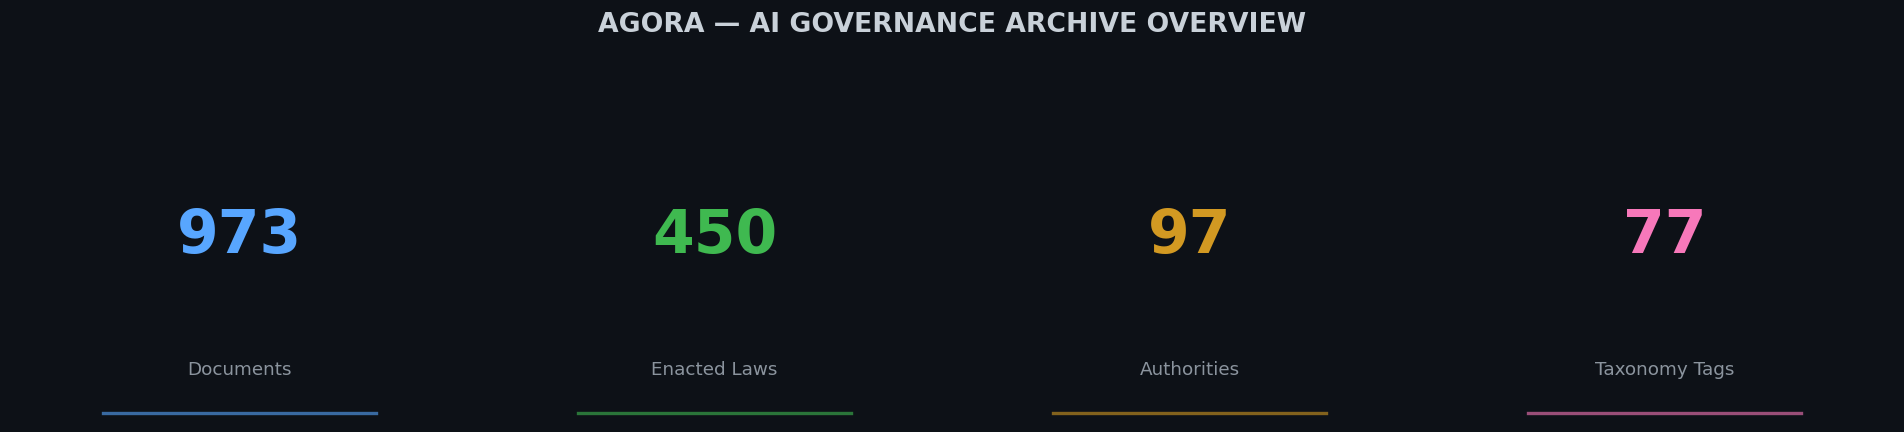

In [20]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
fig.suptitle('AGORA — AI GOVERNANCE ARCHIVE OVERVIEW',
             fontsize=16, fontweight='bold', color=C['text'], y=1.02)

stats = [
    ('Documents', f'{len(docs)}', C['accent']),
    ('Enacted Laws', f'{(docs["Most recent activity"]=="Enacted").sum()}', C['accent2']),
    ('Authorities', f'{docs.Authority.nunique()}', C['accent3']),
    ('Taxonomy Tags', f'{len(tag_cols)}', C['accent4']),
]
for ax, (label, value, color) in zip(axes, stats):
    ax.text(0.5, 0.55, value, fontsize=36, fontweight='bold',
            color=color, ha='center', va='center', transform=ax.transAxes)
    ax.text(0.5, 0.15, label, fontsize=11, color=C['text_dim'],
            ha='center', va='center', transform=ax.transAxes)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.axhline(y=0.02, xmin=0.2, xmax=0.8, color=color, linewidth=2, alpha=0.6)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_01_overview.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.2 Document Status Distribution

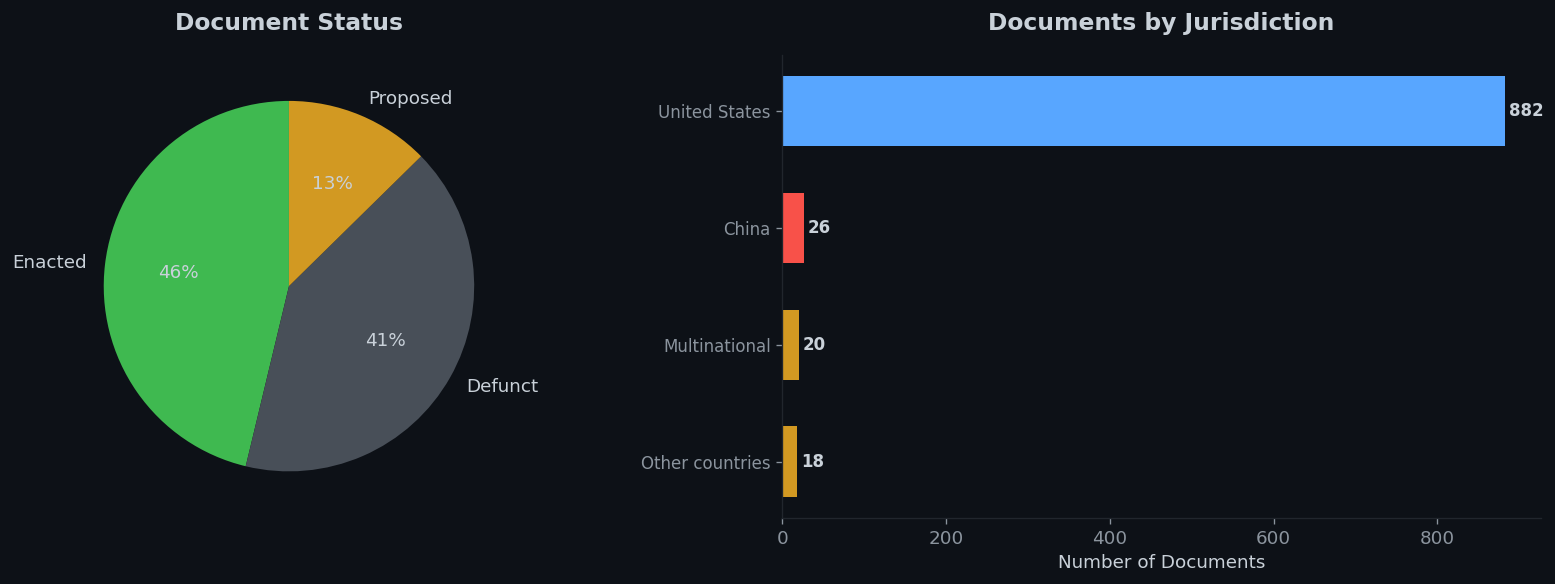

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Status pie
status_counts = master['Most recent activity'].value_counts()
status_colors = [C['accent2'], C['muted'], C['accent3']]
ax1.pie(status_counts.values, labels=status_counts.index, autopct='%1.0f%%',
        colors=status_colors, startangle=90, textprops={'color': C['text'], 'fontsize': 11})
ax1.set_title('Document Status')

# Jurisdiction bar
jur_counts = master['country'].value_counts()
jur_colors = [C['accent'] if j == 'United States' else C['danger'] if j == 'China'
              else C['accent3'] for j in jur_counts.index]
ax2.barh(range(len(jur_counts)), jur_counts.values, color=jur_colors, height=0.6)
ax2.set_yticks(range(len(jur_counts)))
ax2.set_yticklabels(jur_counts.index, fontsize=10)
ax2.invert_yaxis()
for i, val in enumerate(jur_counts.values):
    ax2.text(val + 5, i, str(val), va='center', fontsize=10, fontweight='bold', color=C['text'])
ax2.set_xlabel('Number of Documents')
ax2.set_title('Documents by Jurisdiction')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_02_status.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.3 Governance Activity Timeline

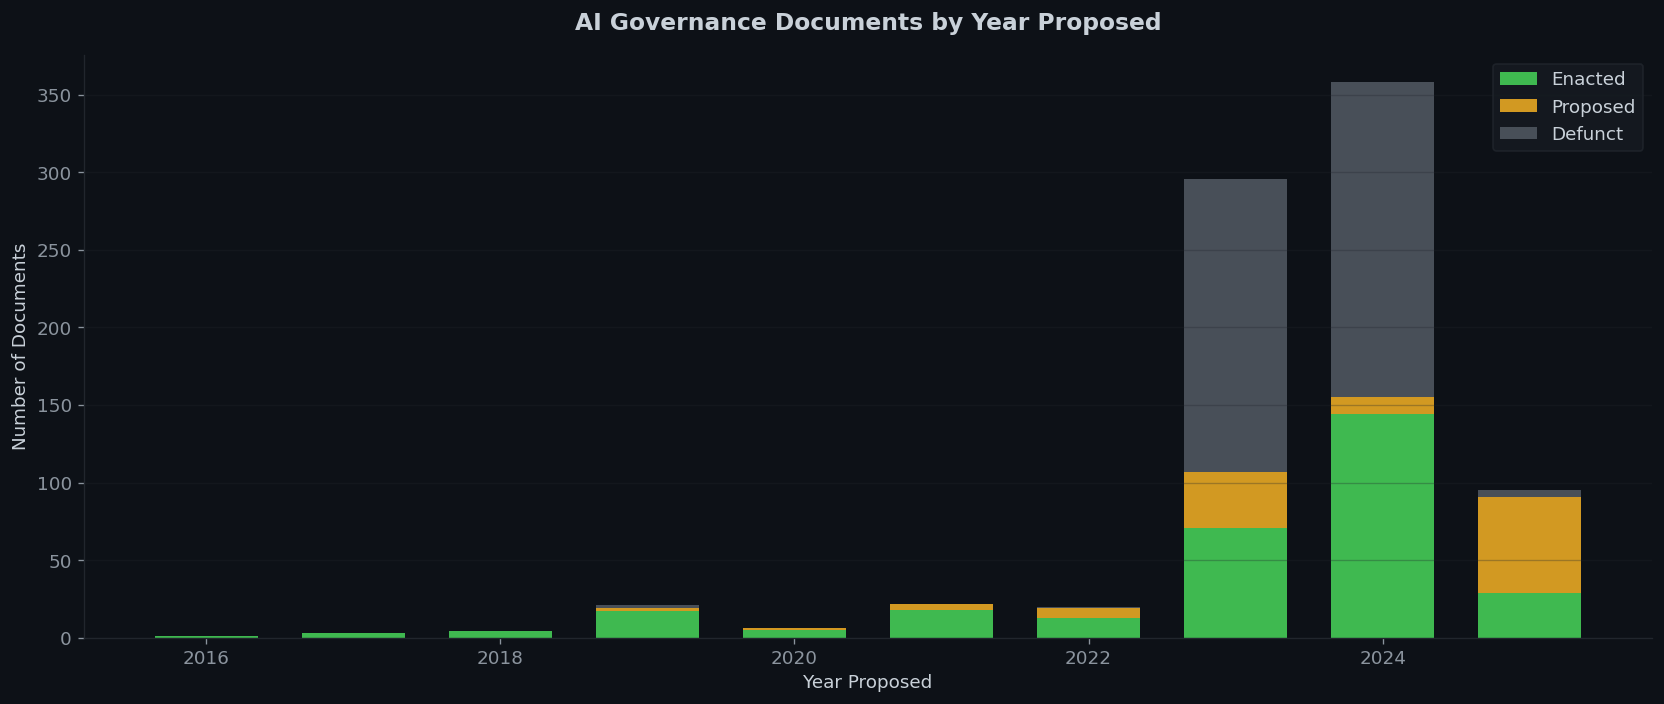

In [22]:
# Documents by year and status
timeline = master.dropna(subset=['proposed_year']).copy()
timeline = timeline[timeline.proposed_year >= 2016]
timeline_pivot = timeline.groupby(['proposed_year', 'Most recent activity']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
status_plot_colors = {'Enacted': C['accent2'], 'Proposed': C['accent3'], 'Defunct': C['muted']}
bottom = np.zeros(len(timeline_pivot))
for status in ['Enacted', 'Proposed', 'Defunct']:
    if status in timeline_pivot.columns:
        vals = timeline_pivot[status].values
        ax.bar(timeline_pivot.index, vals, bottom=bottom, width=0.7,
               color=status_plot_colors[status], label=status, edgecolor='none')
        bottom += vals

ax.set_xlabel('Year Proposed')
ax.set_ylabel('Number of Documents')
ax.set_title('AI Governance Documents by Year Proposed', pad=15)
ax.legend(facecolor=C['surface'], edgecolor=C['border'])
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_03_timeline.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.4 Most Common Tags (Enacted Documents Only)

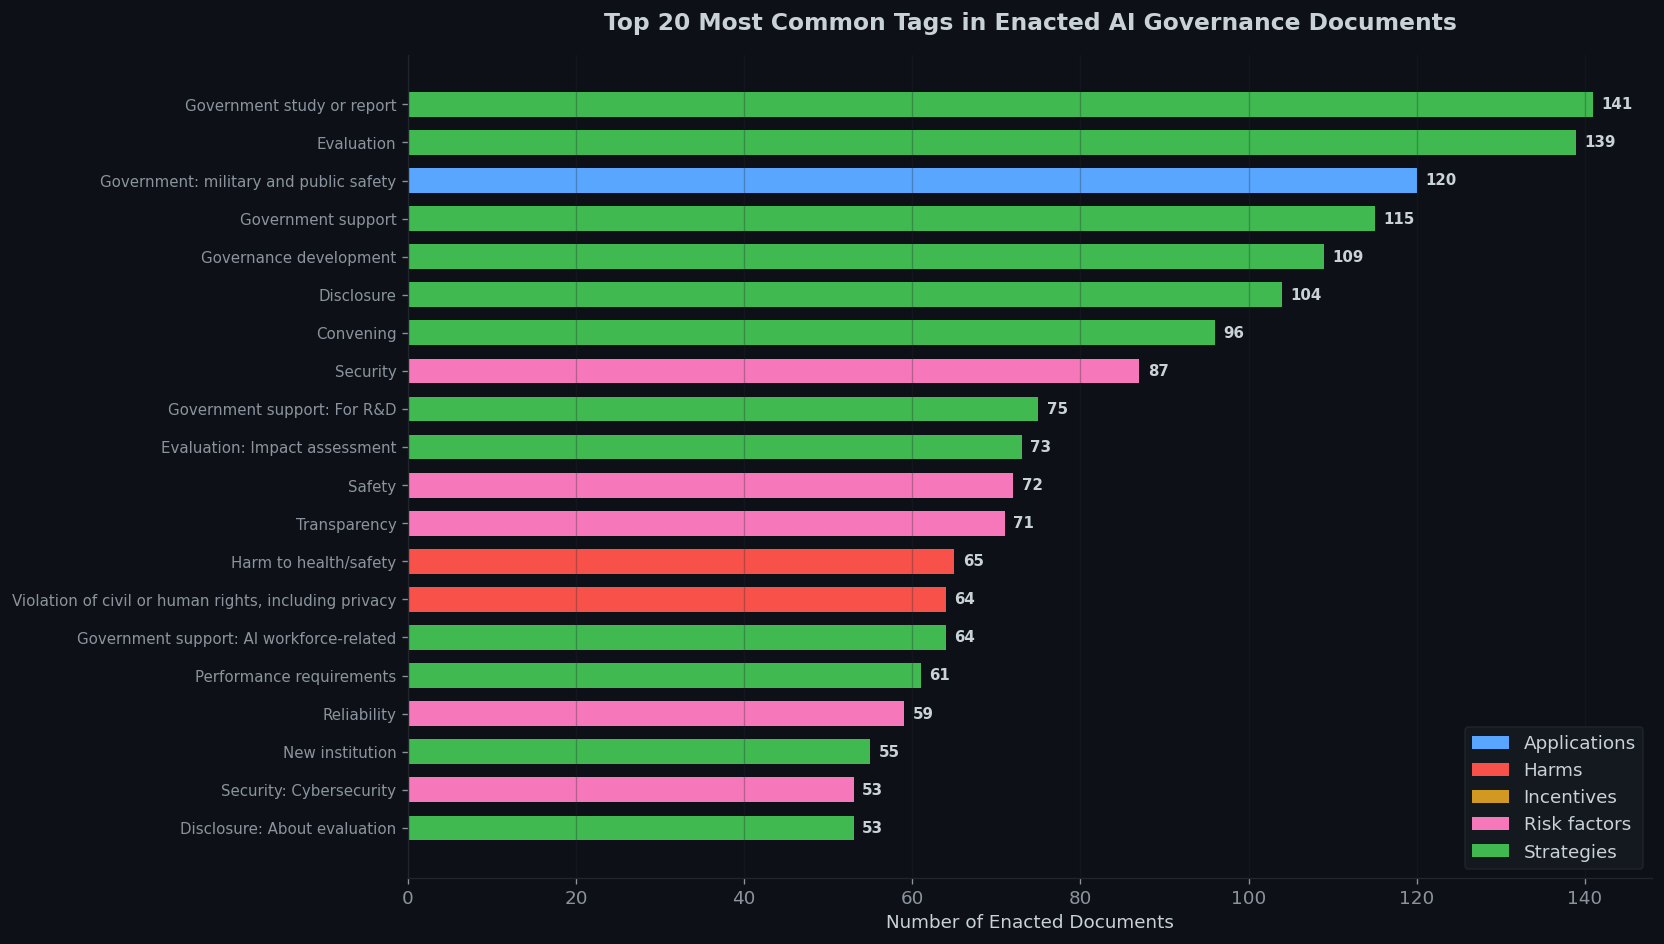

In [23]:
enacted_master = master[master['Most recent activity'] == 'Enacted'].copy()
tag_counts = enacted_master[tag_cols].sum().sort_values(ascending=True).tail(20)

# Color by domain
bar_colors = [DOMAIN_COLORS.get(t.split(':')[0], C['muted']) for t in tag_counts.index]

fig, ax = plt.subplots(figsize=(14, 8))
ax.barh(range(len(tag_counts)), tag_counts.values, color=bar_colors, height=0.65)
ax.set_yticks(range(len(tag_counts)))
# Shorten tag names for display
short_labels = [t.split(': ', 1)[-1] if ': ' in t else t for t in tag_counts.index]
ax.set_yticklabels(short_labels, fontsize=9)
for i, val in enumerate(tag_counts.values):
    ax.text(val + 1, i, str(int(val)), va='center', fontsize=9, fontweight='bold', color=C['text'])

ax.set_xlabel('Number of Enacted Documents')
ax.set_title('Top 20 Most Common Tags in Enacted AI Governance Documents', pad=15)
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

# Domain legend
legend_elements = [Patch(facecolor=color, label=domain) for domain, color in DOMAIN_COLORS.items()]
ax.legend(handles=legend_elements, loc='lower right', facecolor=C['surface'], edgecolor=C['border'])

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_04_top_tags.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.5 Tag Domain Distribution (Enacted Documents)

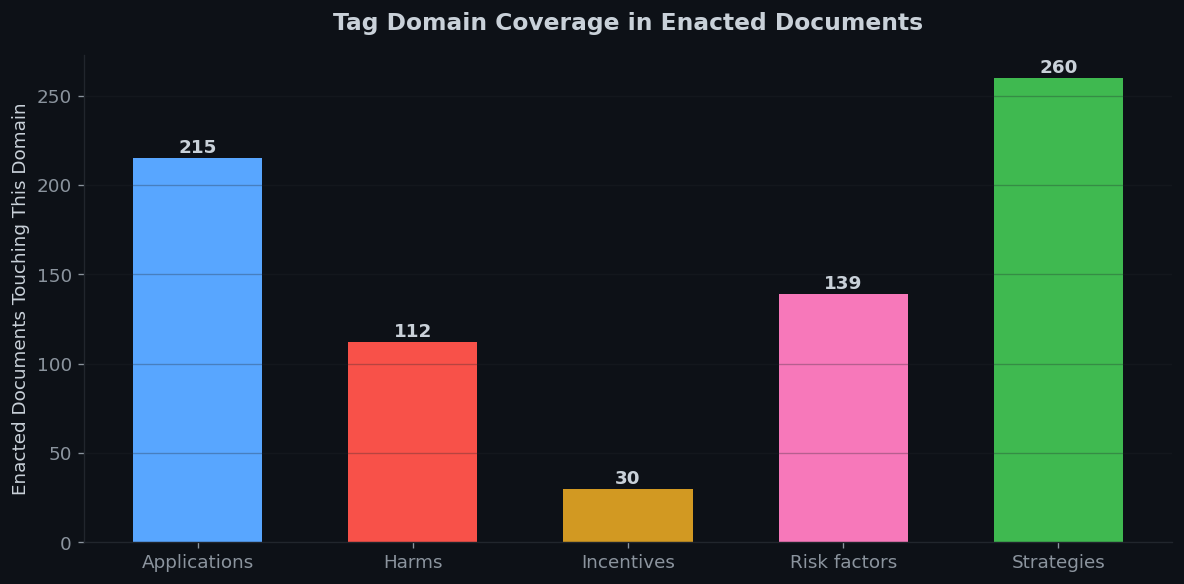

In [24]:
domain_sums = {}
for domain in ['Applications', 'Harms', 'Incentives', 'Risk factors', 'Strategies']:
    domain_cols_subset = [c for c in tag_cols if c.startswith(domain)]
    domain_sums[domain] = enacted_master[domain_cols_subset].any(axis=1).sum()

fig, ax = plt.subplots(figsize=(10, 5))
domains = list(domain_sums.keys())
values = list(domain_sums.values())
colors = [DOMAIN_COLORS[d] for d in domains]

bars = ax.bar(domains, values, color=colors, edgecolor='none', width=0.6)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', fontsize=11, fontweight='bold', color=C['text'])

ax.set_ylabel('Enacted Documents Touching This Domain')
ax.set_title('Tag Domain Coverage in Enacted Documents', pad=15)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_05_domains.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.6 Government vs Private Sector Focus

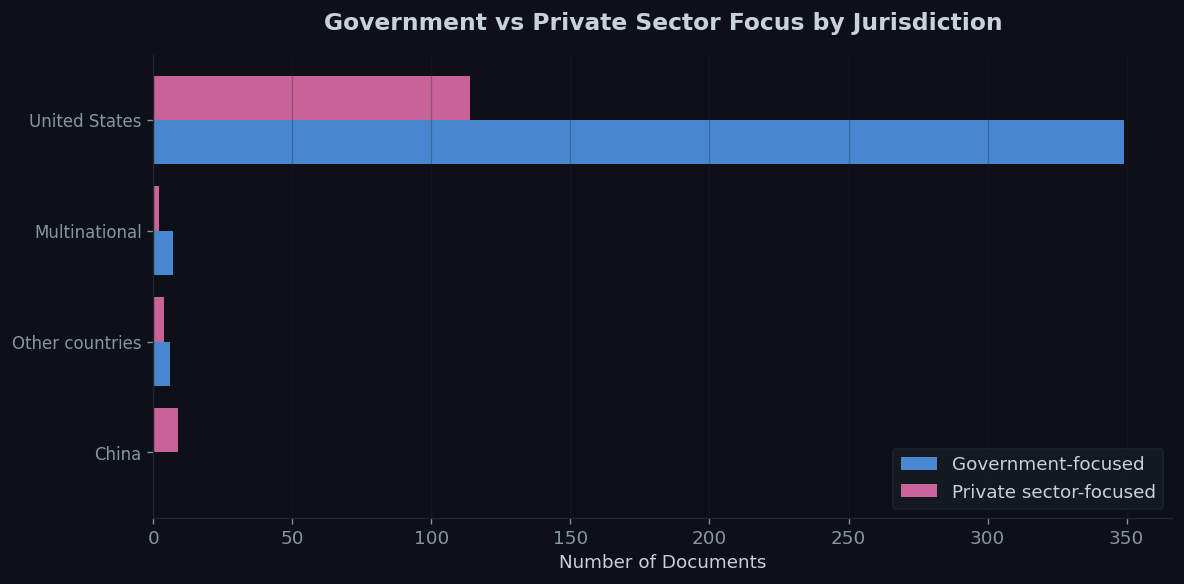

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

focus_data = master.groupby('country').agg(
    gov=('Primarily applies to the government', 'sum'),
    private=('Primarily applies to the private sector', 'sum')
).sort_values('gov', ascending=True)

y = range(len(focus_data))
ax.barh(y, focus_data['gov'], height=0.4, color=C['accent'], label='Government-focused', alpha=0.8)
ax.barh([i + 0.4 for i in y], focus_data['private'], height=0.4, color=C['accent4'], label='Private sector-focused', alpha=0.8)
ax.set_yticks([i + 0.2 for i in y])
ax.set_yticklabels(focus_data.index, fontsize=10)

ax.set_xlabel('Number of Documents')
ax.set_title('Government vs Private Sector Focus by Jurisdiction', pad=15)
ax.legend(facecolor=C['surface'], edgecolor=C['border'])
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_06_gov_private.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.7 Tags per Document Distribution

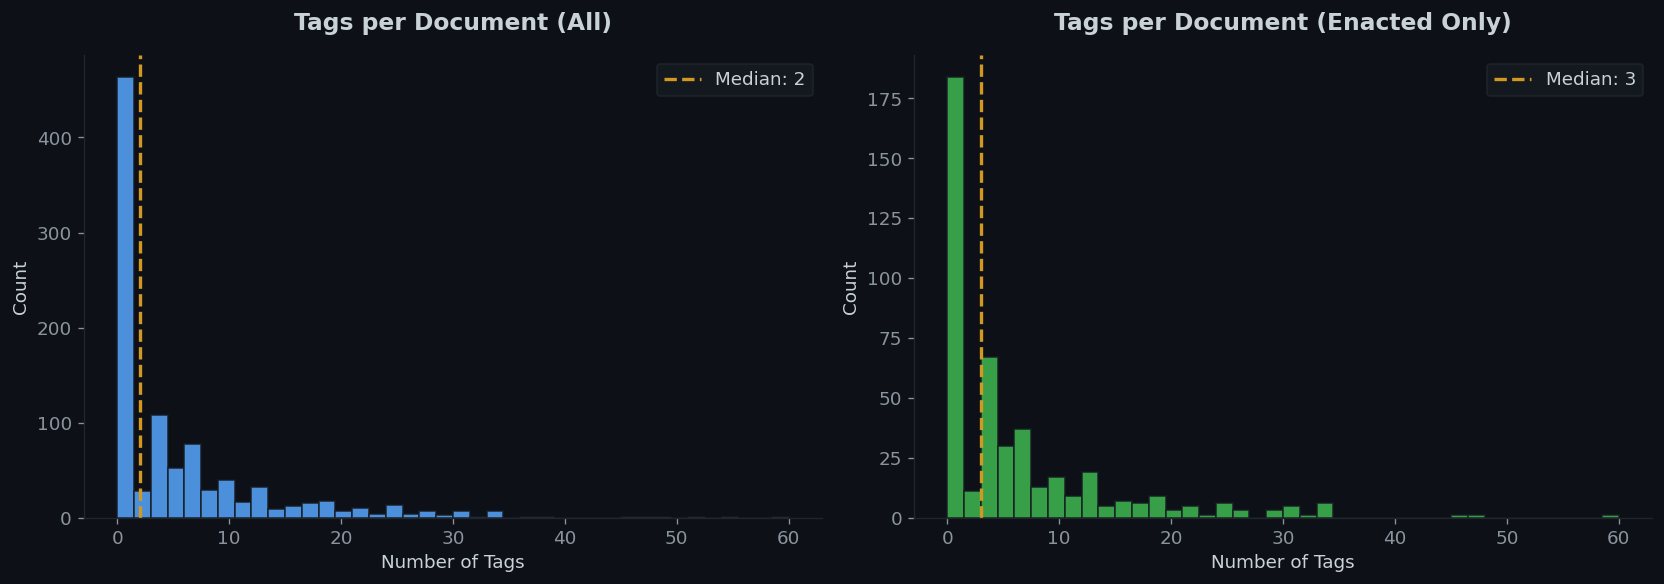

In [26]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# All docs
ax1.hist(master['num_tags'], bins=40, color=C['accent'], edgecolor=C['surface'], alpha=0.85)
ax1.axvline(master.num_tags.median(), color=C['accent3'], linestyle='--', linewidth=2,
            label=f'Median: {master.num_tags.median():.0f}')
ax1.set_title('Tags per Document (All)')
ax1.set_xlabel('Number of Tags'); ax1.set_ylabel('Count')
ax1.legend(facecolor=C['surface'], edgecolor=C['border'])
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Enacted only
enacted_tags = master[master['Most recent activity'] == 'Enacted']['num_tags']
ax2.hist(enacted_tags, bins=40, color=C['accent2'], edgecolor=C['surface'], alpha=0.85)
ax2.axvline(enacted_tags.median(), color=C['accent3'], linestyle='--', linewidth=2,
            label=f'Median: {enacted_tags.median():.0f}')
ax2.set_title('Tags per Document (Enacted Only)')
ax2.set_xlabel('Number of Tags'); ax2.set_ylabel('Count')
ax2.legend(facecolor=C['surface'], edgecolor=C['border'])
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_07_tag_dist.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.8 Documents by Collection

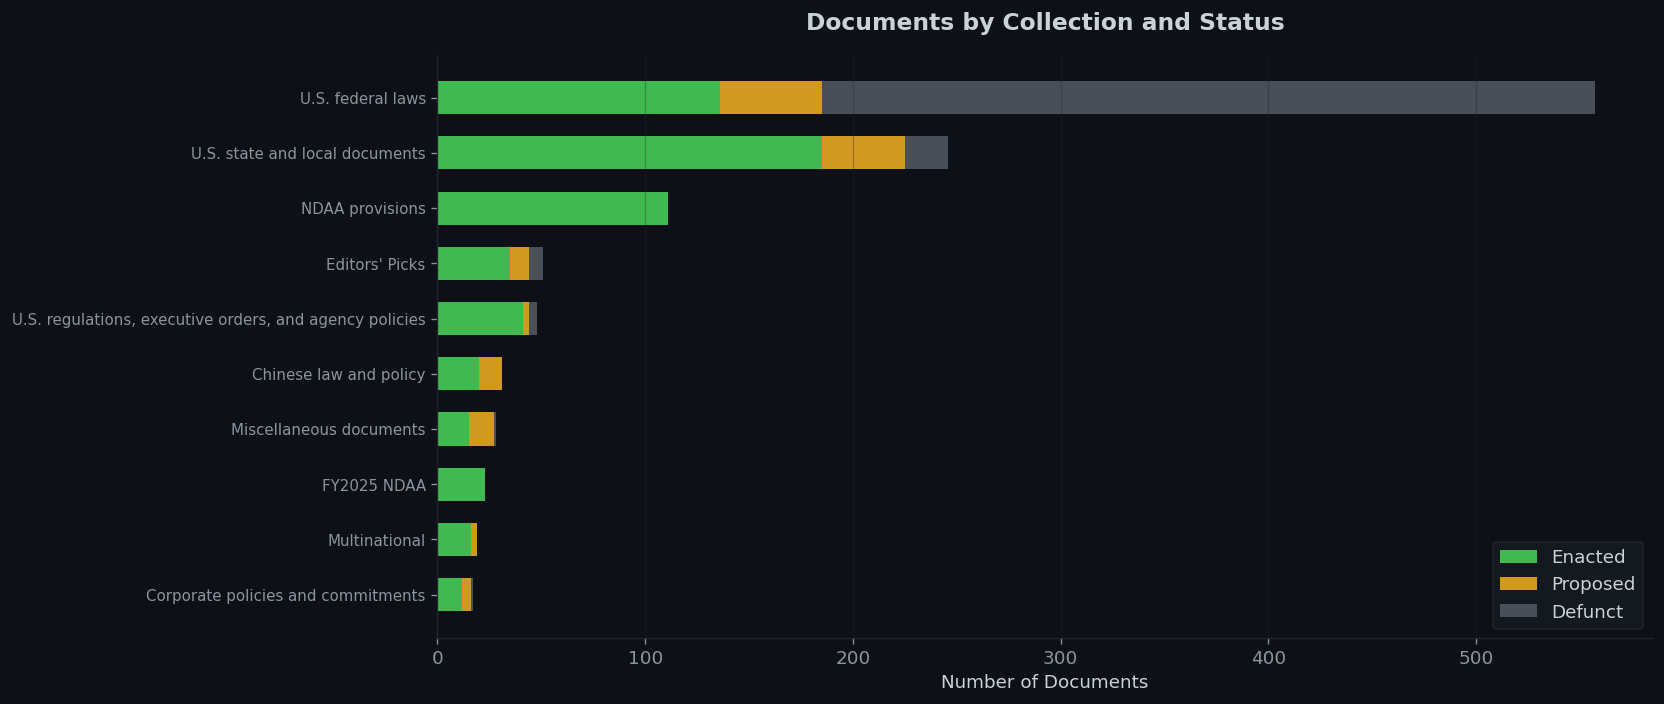

In [27]:
coll_expanded = master[['AGORA ID', 'Collections', 'Most recent activity']].copy()
coll_expanded = coll_expanded.dropna(subset=['Collections'])
coll_expanded = coll_expanded.assign(
    Collection=coll_expanded['Collections'].str.split(';')
).explode('Collection')
coll_expanded['Collection'] = coll_expanded['Collection'].str.strip()

coll_status = coll_expanded.groupby(['Collection', 'Most recent activity']).size().unstack(fill_value=0)
coll_status['total'] = coll_status.sum(axis=1)
coll_status = coll_status.sort_values('total', ascending=True)

fig, ax = plt.subplots(figsize=(14, 6))
y = range(len(coll_status))
left = np.zeros(len(coll_status))
for status in ['Enacted', 'Proposed', 'Defunct']:
    if status in coll_status.columns:
        vals = coll_status[status].values
        ax.barh(y, vals, left=left, height=0.6,
                color=status_plot_colors.get(status, C['muted']), label=status, edgecolor='none')
        left += vals

ax.set_yticks(y)
ax.set_yticklabels(coll_status.index, fontsize=9)
ax.set_xlabel('Number of Documents')
ax.set_title('Documents by Collection and Status', pad=15)
ax.legend(facecolor=C['surface'], edgecolor=C['border'])
ax.grid(axis='x', alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_08_collections.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.9 Tag Domain Co-occurrence (Enacted Documents)

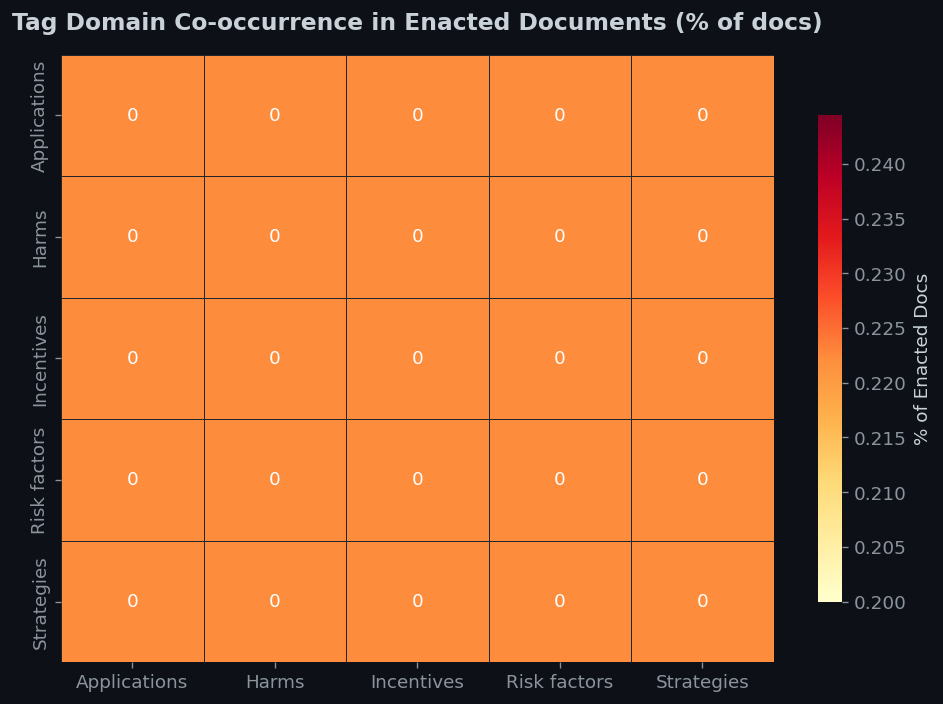

In [28]:
# Which tag domains co-occur most frequently?
domain_flags = pd.DataFrame()
for domain in ['Applications', 'Harms', 'Incentives', 'Risk factors', 'Strategies']:
    domain_cols_subset = [c for c in tag_cols if c.startswith(domain)]
    domain_flags[domain] = enacted_master[domain_cols_subset].any(axis=1)

# Co-occurrence matrix
co_matrix = domain_flags.T.dot(domain_flags)
# Normalize to percentage
co_pct = co_matrix / len(enacted_master) * 100

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(co_pct, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor=C['border'],
            cbar_kws={'label': '% of Enacted Docs', 'shrink': 0.8}, ax=ax)
ax.set_title('Tag Domain Co-occurrence in Enacted Documents (% of docs)', pad=15)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_09_cooccurrence.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

### 6.10 AISI Governance Readiness Preview

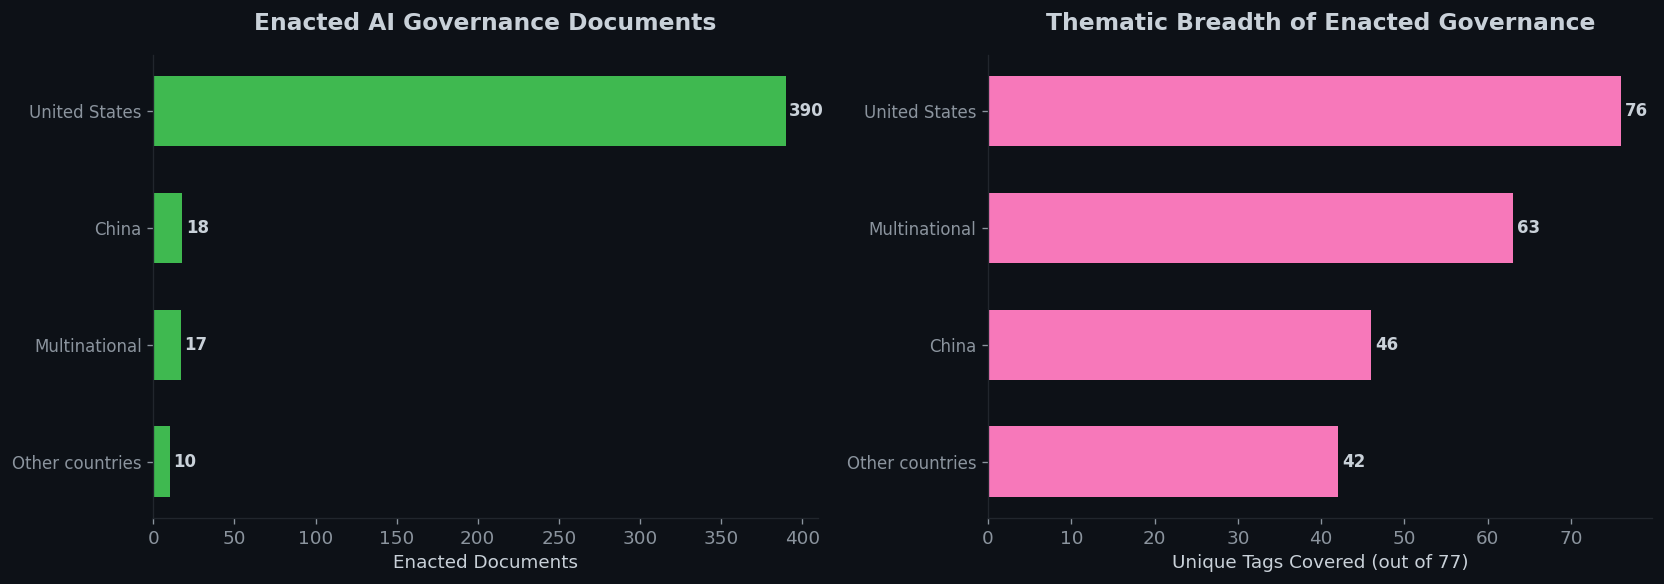

In [29]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

gm = governance_metrics.sort_values('enacted_docs', ascending=True)

# Enacted docs
ax1.barh(range(len(gm)), gm['enacted_docs'], color=C['accent2'], height=0.6)
ax1.set_yticks(range(len(gm)))
ax1.set_yticklabels(gm['country'], fontsize=10)
for i, val in enumerate(gm['enacted_docs']):
    ax1.text(val + 2, i, str(val), va='center', fontsize=10, fontweight='bold', color=C['text'])
ax1.set_xlabel('Enacted Documents')
ax1.set_title('Enacted AI Governance Documents')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Thematic breadth
gm2 = governance_metrics.sort_values('thematic_breadth', ascending=True)
ax2.barh(range(len(gm2)), gm2['thematic_breadth'], color=C['accent4'], height=0.6)
ax2.set_yticks(range(len(gm2)))
ax2.set_yticklabels(gm2['country'], fontsize=10)
for i, val in enumerate(gm2['thematic_breadth']):
    ax2.text(val + 0.5, i, str(val), va='center', fontsize=10, fontweight='bold', color=C['text'])
ax2.set_xlabel(f'Unique Tags Covered (out of {len(tag_cols)})')
ax2.set_title('Thematic Breadth of Enacted Governance')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{OUT}agora_viz_10_aisi_readiness.png', bbox_inches='tight', facecolor=C['bg'], dpi=150)
plt.show()

---
## 7. AISI Pipeline Preview — Governance Readiness Dimension

In [30]:
print('AISI Governance Readiness — Final Metrics')
print('=' * 90)
print(f'\nDimension weight: 9%')
print(f'Sub-components:')
print(f'  Document count (30%) — log-transformed enacted documents')
print(f'  Thematic breadth (40%) — unique tags across enacted docs (out of {len(tag_cols)})')
print(f'  Maturity ratio (30%) — enacted / total documents')
print(f'\nMetrics by jurisdiction:')
display_cols = ['country', 'enacted_docs', 'thematic_breadth', 'maturity_ratio', 'total_docs']
print(governance_metrics[display_cols].to_string(index=False, float_format='%.2f'))
print(f'\n⚠️ Only {len(governance_metrics)} jurisdictions currently covered')
print(f'  US dominates with {governance_metrics.iloc[0].enacted_docs:.0f} enacted docs and '
      f'{governance_metrics.iloc[0].thematic_breadth:.0f} unique tags')

AISI Governance Readiness — Final Metrics

Dimension weight: 9%
Sub-components:
  Document count (30%) — log-transformed enacted documents
  Thematic breadth (40%) — unique tags across enacted docs (out of 77)
  Maturity ratio (30%) — enacted / total documents

Metrics by jurisdiction:
        country  enacted_docs  thematic_breadth  maturity_ratio  total_docs
  United States           390                76            0.44         882
          China            18                46            0.69          26
  Multinational            17                63            0.85          20
Other countries            10                42            0.56          18

⚠️ Only 4 jurisdictions currently covered
  US dominates with 390 enacted docs and 76 unique tags


---
## Done ✓

**Outputs saved:**
- `agora_master.csv` — Enriched master dataset (973 docs × 100+ columns with jurisdiction mapping)
- `agora_governance_metrics.csv` — AISI-ready governance metrics per jurisdiction
- 10 visualization PNGs

**Key findings:**
1. **91% US-focused** — 882/973 documents are from US jurisdictions (federal + state)
2. **450 enacted documents** — the rest are proposed (123) or defunct (400)
3. **77 thematic tags** across 5 domains: Applications (19), Strategies (34), Risk factors (10), Harms (8), Incentives (6)
4. **Strategies dominate** — 'Government study/report', 'Evaluation', and 'Governance development' are the most common enacted tags
5. **46% of documents have zero tags** — mostly unannotated docs still awaiting human review
6. **China has 26 documents** (18 enacted) with 48 unique tags — limited but meaningful
7. **Governance is accelerating** — steep increase in proposed and enacted documents from 2022 onwards

**AISI implications:**
- Only 4 jurisdictions currently scoreable (US, China, Multinational, Other)
- The coverage-weighted composite will treat most countries as having no governance data
- As AGORA expands coverage, governance scoring will improve without methodology changes